In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from tqdm.auto import tqdm
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import joblib

warnings.filterwarnings('ignore')

def locate_root():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'data').exists():
            return candidate
    return current

root = locate_root()
data_dir = root / 'data'
metadata_dir = data_dir / 'metadata'
processed_dir = data_dir / 'processed'
models_dir = root / 'models'
reports_dir = root / 'reports'
figures_dir = reports_dir / 'figures'
tables_dir = reports_dir / 'tables'

for d in [models_dir, figures_dir, tables_dir]:
    d.mkdir(parents=True, exist_ok=True)

print('Root:', root)

/home/hamza/Documents/aero-res/aircraft_fault_localization/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Root: /home/hamza/Documents/aero-res/aircraft_fault_localization


In [2]:
standardized_df = pd.read_parquet(processed_dir / 'flight_rows_standardized.parquet')
feature_manifest = pd.read_csv(metadata_dir / 'feature_manifest.csv')

pca_features = feature_manifest[
    (feature_manifest['healthy_non_null_ratio'].fillna(0) >= 0.8) &
    (feature_manifest['defective_non_null_ratio'].fillna(0) >= 0.4)
]['feature'].astype(str).tolist()

meta_cols = ['file_name', 'group', 'sequence_index', 'time_index']
available_features = [c for c in pca_features if c in standardized_df.columns]

healthy_df = standardized_df[standardized_df['group'] == 'healthy'].copy()
defective_df = standardized_df[standardized_df['group'] == 'defective'].copy()

print(f'Features selected : {len(available_features)}')
print(f'Healthy rows       : {len(healthy_df):,}')
print(f'Defective rows     : {len(defective_df):,}')

Features selected : 178
Healthy rows       : 142,391
Defective rows     : 170,110


In [3]:
X_healthy = healthy_df[available_features].fillna(0).astype(np.float32)
X_defective = defective_df[available_features].fillna(0).astype(np.float32)
X_all = standardized_df[available_features].fillna(0).astype(np.float32)

MAX_TRAIN = 50_000
if len(X_healthy) > MAX_TRAIN:
    train_idx = np.random.default_rng(42).choice(len(X_healthy), MAX_TRAIN, replace=False)
    X_train = X_healthy.iloc[train_idx]
else:
    X_train = X_healthy

print(f'Training rows: {len(X_train):,}')

Training rows: 50,000


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_all_scaled = scaler.transform(X_all)
X_healthy_scaled = scaler.transform(X_healthy)
X_defective_scaled = scaler.transform(X_defective)

In [5]:
n_components_threshold = 0.95
pca_pre = PCA(n_components=n_components_threshold, random_state=42)
pca_pre.fit(X_train_scaled)
n_components = pca_pre.n_components_
cum_var = np.cumsum(pca_pre.explained_variance_ratio_)
print(f'PCA pre-reduction: {n_components} components explaining {cum_var[-1]:.3f} variance')

X_train_pca = pca_pre.transform(X_train_scaled)
X_all_pca = pca_pre.transform(X_all_scaled)
X_healthy_pca = pca_pre.transform(X_healthy_scaled)
X_defective_pca = pca_pre.transform(X_defective_scaled)

PCA pre-reduction: 43 components explaining 0.952 variance


In [6]:
print('Training Isolation Forest ...')
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_pca)

iso_scores_all = iso_forest.decision_function(X_all_pca)
iso_preds_all = iso_forest.predict(X_all_pca)

print('Isolation Forest training complete')

Training Isolation Forest ...
Isolation Forest training complete


In [7]:
print('Training One-Class SVM ...')
ocsvm_sample_size = min(10_000, len(X_train_pca))
rng = np.random.default_rng(0)
svm_idx = rng.choice(len(X_train_pca), ocsvm_sample_size, replace=False)
X_svm_train = X_train_pca[svm_idx]

ocsvm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
ocsvm.fit(X_svm_train)

ocsvm_scores_all = ocsvm.decision_function(X_all_pca)
ocsvm_preds_all = ocsvm.predict(X_all_pca)

print('One-Class SVM training complete')

Training One-Class SVM ...
One-Class SVM training complete


In [8]:
def pca_reconstruction_score(X, pca, scaler_obj=None):
    if scaler_obj is not None:
        X = scaler_obj.transform(X)
    X_proj = pca.transform(X)
    X_recon = pca.inverse_transform(X_proj)
    spe = np.sum((X - X_recon) ** 2, axis=1)
    eigenvalues = np.maximum(pca.explained_variance_, 1e-10)
    t2 = np.sum((X_proj ** 2) / eigenvalues, axis=1)
    return spe, t2

print('Computing PCA reconstruction scores ...')
pca_recon = PCA(n_components=n_components, random_state=42)
pca_recon.fit(X_train_scaled)

spe_all, t2_all = pca_reconstruction_score(X_all.values, pca_recon, scaler)
spe_healthy, t2_healthy = pca_reconstruction_score(X_healthy.values, pca_recon, scaler)

spe_threshold_95 = np.percentile(spe_healthy, 95)
spe_threshold_99 = np.percentile(spe_healthy, 99)
t2_threshold_95 = np.percentile(t2_healthy, 95)
t2_threshold_99 = np.percentile(t2_healthy, 99)

print(f'SPE 95th pct threshold  : {spe_threshold_95:.4f}')
print(f'SPE 99th pct threshold  : {spe_threshold_99:.4f}')
print(f'T2  95th pct threshold  : {t2_threshold_95:.4f}')
print(f'T2  99th pct threshold  : {t2_threshold_99:.4f}')

Computing PCA reconstruction scores ...
SPE 95th pct threshold  : 23.4479
SPE 99th pct threshold  : 68.0998
T2  95th pct threshold  : 110.8931
T2  99th pct threshold  : 420.9377


In [9]:
results_df = standardized_df[meta_cols].copy()
results_df['iso_score'] = iso_scores_all
results_df['iso_anomaly'] = (iso_preds_all == -1).astype(int)
results_df['ocsvm_score'] = ocsvm_scores_all
results_df['ocsvm_anomaly'] = (ocsvm_preds_all == -1).astype(int)
results_df['spe'] = spe_all
results_df['t2'] = t2_all
results_df['spe_anomaly_95'] = (spe_all > spe_threshold_95).astype(int)
results_df['spe_anomaly_99'] = (spe_all > spe_threshold_99).astype(int)
results_df['t2_anomaly_95'] = (t2_all > t2_threshold_95).astype(int)
results_df['t2_anomaly_99'] = (t2_all > t2_threshold_99).astype(int)

ensemble_votes = (
    results_df['iso_anomaly'] +
    results_df['ocsvm_anomaly'] +
    results_df['spe_anomaly_95'] +
    results_df['t2_anomaly_95']
)
results_df['ensemble_votes'] = ensemble_votes
results_df['ensemble_anomaly'] = (ensemble_votes >= 2).astype(int)

results_df.to_parquet(processed_dir / 'anomaly_model_scores.parquet', index=False)
print('Scores saved.')
print(results_df[['group', 'iso_anomaly', 'ocsvm_anomaly', 'spe_anomaly_95', 'ensemble_anomaly']].groupby('group').mean().round(3))

Scores saved.
           iso_anomaly  ocsvm_anomaly  spe_anomaly_95  ensemble_anomaly
group                                                                  
defective        0.298          0.364           0.867             0.378
healthy          0.050          0.054           0.050             0.053


In [10]:
file_model_summary = results_df.groupby(['group', 'file_name']).agg(
    total_rows=('sequence_index', 'count'),
    iso_anomaly_rate=('iso_anomaly', 'mean'),
    ocsvm_anomaly_rate=('ocsvm_anomaly', 'mean'),
    spe_anomaly_rate_95=('spe_anomaly_95', 'mean'),
    t2_anomaly_rate_95=('t2_anomaly_95', 'mean'),
    ensemble_anomaly_rate=('ensemble_anomaly', 'mean'),
    mean_spe=('spe', 'mean'),
    max_spe=('spe', 'max'),
    mean_iso_score=('iso_score', 'mean'),
).reset_index()

file_model_summary.to_csv(tables_dir / 'anomaly_model_file_summary.csv', index=False)
print(file_model_summary.sort_values('ensemble_anomaly_rate', ascending=False).head(10).to_string(index=False))

    group         file_name  total_rows  iso_anomaly_rate  ocsvm_anomaly_rate  spe_anomaly_rate_95  t2_anomaly_rate_95  ensemble_anomaly_rate   mean_spe      max_spe  mean_iso_score
defective Defect15(02).xlsx        4902          0.997552            0.996736                  1.0            0.996532               0.997960 522.813965 13680.480469       -0.130172
defective   Defected 2.xlsx        4902          0.997552            0.996736                  1.0            0.996532               0.997960 522.813965 13680.480469       -0.130172
defective Defect16(01).xlsx        9690          0.530031            0.929721                  1.0            0.659752               0.945717 252.391098   952.317627       -0.016489
defective   Defected 5.xlsx        9690          0.530031            0.929721                  1.0            0.659752               0.945717 252.391098   952.317749       -0.016489
defective   Defected 1.xlsx       12431          0.575899            0.640656             

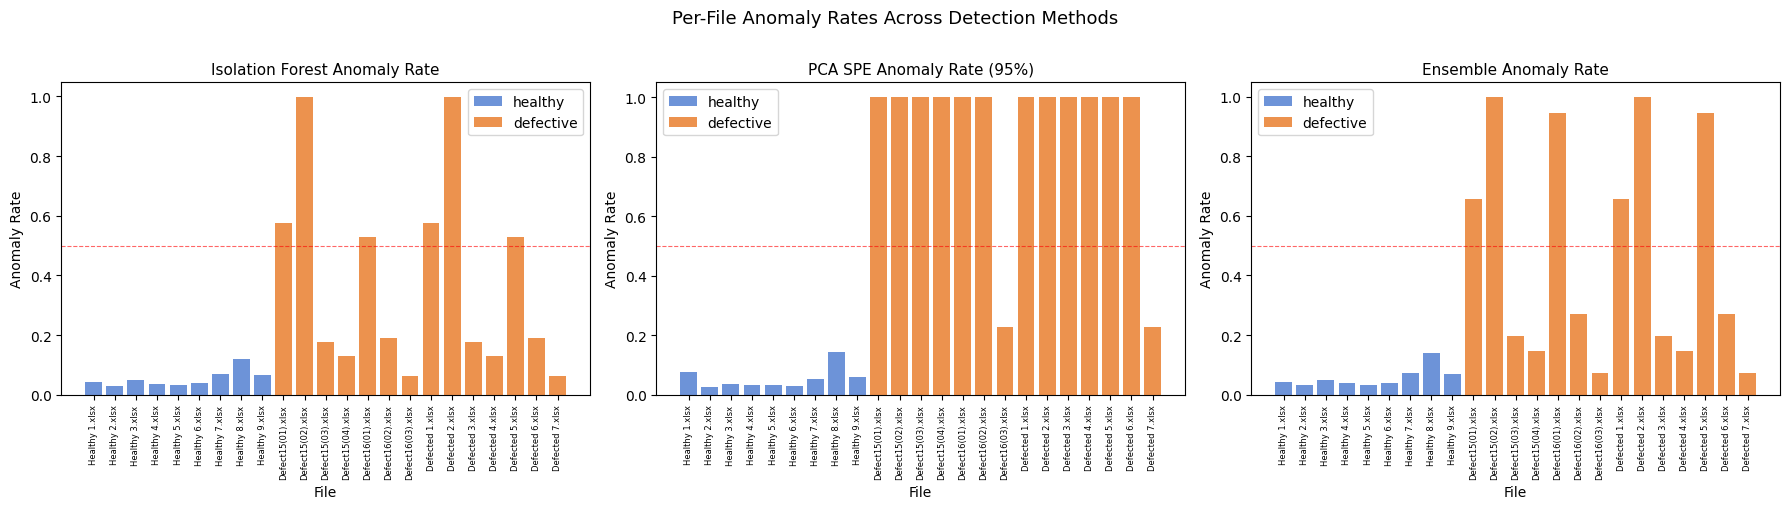

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, label in zip(
    axes,
    ['iso_anomaly_rate', 'spe_anomaly_rate_95', 'ensemble_anomaly_rate'],
    ['Isolation Forest Anomaly Rate', 'PCA SPE Anomaly Rate (95%)', 'Ensemble Anomaly Rate']
):
    for group, color in [('healthy', '#4878CF'), ('defective', '#E87722')]:
        subset = file_model_summary[file_model_summary['group'] == group]
        ax.bar(subset['file_name'], subset[col], color=color, alpha=0.8, label=group)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('File')
    ax.set_ylabel('Anomaly Rate')
    ax.tick_params(axis='x', rotation=90, labelsize=6)
    ax.legend()
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.6)

plt.suptitle('Per-File Anomaly Rates Across Detection Methods', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(figures_dir / 'anomaly_model_file_rates.png', dpi=150, bbox_inches='tight')
plt.show()

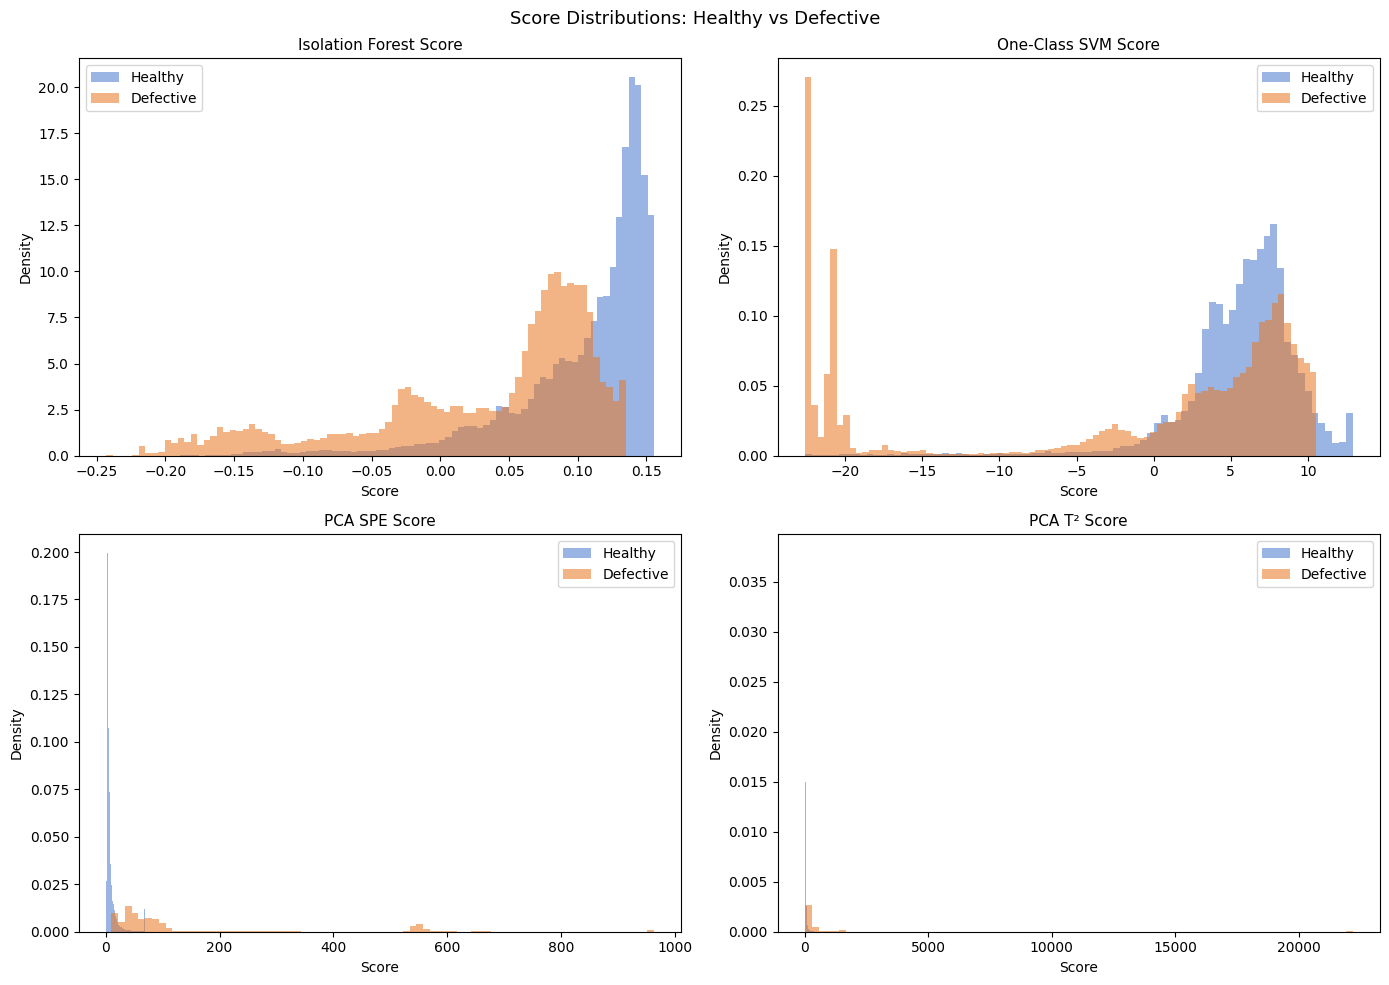

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

score_pairs = [
    ('iso_score', 'Isolation Forest Score'),
    ('ocsvm_score', 'One-Class SVM Score'),
    ('spe', 'PCA SPE Score'),
    ('t2', 'PCA T² Score'),
]

for ax, (col, title) in zip(axes.flat, score_pairs):
    for group, color, label in [('healthy', '#4878CF', 'Healthy'), ('defective', '#E87722', 'Defective')]:
        vals = results_df.loc[results_df['group'] == group, col]
        cap = np.percentile(vals, 99)
        vals_clipped = vals.clip(upper=cap)
        ax.hist(vals_clipped, bins=80, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Score Distributions: Healthy vs Defective', fontsize=13)
plt.tight_layout()
plt.savefig(figures_dir / 'anomaly_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
joblib.dump({
    'scaler': scaler,
    'pca_pre': pca_pre,
    'pca_recon': pca_recon,
    'iso_forest': iso_forest,
    'ocsvm': ocsvm,
    'spe_threshold_95': spe_threshold_95,
    'spe_threshold_99': spe_threshold_99,
    't2_threshold_95': t2_threshold_95,
    't2_threshold_99': t2_threshold_99,
    'features': available_features,
    'n_components': n_components
}, models_dir / 'anomaly_models.pkl')

threshold_summary = pd.DataFrame([
    {'model': 'PCA_SPE', 'threshold_95': spe_threshold_95, 'threshold_99': spe_threshold_99},
    {'model': 'PCA_T2', 'threshold_95': t2_threshold_95, 'threshold_99': t2_threshold_99},
])
threshold_summary.to_csv(tables_dir / 'anomaly_threshold_summary.csv', index=False)

print('Models and thresholds saved.')

Models and thresholds saved.
